# 1. 라이브러리 및 환경 설정

In [1]:
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv",
    "ChatbotData.csv"
)
print("받았다")

받았다


# 2. 데이터 로드 및 전처리

In [2]:
# === 2. 데이터 로드 + 전처리 ===
# [핵심] 깃허브에서 직접 다운로드 — 로컬에 없을 때
CHATBOT_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
chatbot_df = pd.read_csv(CHATBOT_URL)

def preprocess_sentence(sentence):
    if pd.isna(sentence):
        return ""
    sentence = unicodedata.normalize("NFC", str(sentence))
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^ㄱ-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

df_clean = chatbot_df.copy()
df_clean["Q_clean"] = df_clean["Q"].map(preprocess_sentence)
df_clean["A_clean"] = df_clean["A"].map(preprocess_sentence)
df_clean = df_clean[(df_clean["Q_clean"] != "") & (df_clean["A_clean"] != "")].reset_index(drop=True)

print("전체:", len(df_clean))
df_clean.head(3)

NameError: name 'pd' is not defined

In [ ]:
# 3. 학습 / 검증 데이터 분리

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm

import math, re, unicodedata
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# 4. SentencePiece 토크나이저 학습

In [4]:
CHATBOT_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
chatbot_df = pd.read_csv(CHATBOT_URL)

def preprocess_sentence(sentence):
    if pd.isna(sentence):
        return ""
    sentence = unicodedata.normalize("NFC", str(sentence))
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^ㄱ-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

df_clean = chatbot_df.copy()
df_clean["Q_clean"] = df_clean["Q"].map(preprocess_sentence)
df_clean["A_clean"] = df_clean["A"].map(preprocess_sentence)
df_clean = df_clean[(df_clean["Q_clean"] != "") & (df_clean["A_clean"] != "")].reset_index(drop=True)

print("전체:", len(df_clean))
df_clean.head(3)

전체: 11823


,Q,A,label,Q_clean,A_clean
0,12시 땡!,하루가 또 가네요.,0,12시 땡 !,하루가 또 가네요 .
1,1지망 학교 떨어졌어,위로해 드립니다.,0,1지망 학교 떨어졌어,위로해 드립니다 .
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0,3박4일 놀러가고 싶다,여행은 언제나 좋죠 .


In [5]:
train_df, val_df = train_test_split(
    df_clean, test_size=0.1, random_state=42, stratify=df_clean["label"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print("train:", len(train_df), "/ val:", len(val_df))

train: 10640 / val: 1183


In [6]:
VOCAB_SIZE = 4000
PROJECT_DIR = Path.cwd()
spm_model_prefix = PROJECT_DIR / "spm_korean_chatbot_unigram"
spm_model_path = spm_model_prefix.with_suffix(".model")
spm_corpus_path = PROJECT_DIR / "spm_korean_chatbot_train_corpus.txt"

# [핵심] 토크나이저 학습용 코퍼스 생성 후 SentencePiece 학습
if not spm_model_path.exists():
    with open(spm_corpus_path, "w", encoding="utf-8") as f:
        for q, a in train_df[["Q_clean", "A_clean"]].itertuples(index=False):
            f.write(q + "\n")
            f.write(a + "\n")
    spm.SentencePieceTrainer.Train(
        input=str(spm_corpus_path),
        model_prefix=str(spm_model_prefix),
        vocab_size=VOCAB_SIZE,
        character_coverage=1.0,
        model_type="unigram",
        # [핵심] 특수 토큰 ID를 0~3에 고정 → 모델이 PAD/BOS/EOS/UNK를 정확히 식별
        pad_id=0, bos_id=1, eos_id=2, unk_id=3,
        pad_piece="<pad>", bos_piece="<s>", eos_piece="</s>", unk_piece="<unk>",
        hard_vocab_limit=False,
    )
    print("토크나이저 학습 완료")
else:
    print("기존 토크나이저 사용")

sp = spm.SentencePieceProcessor()
sp.Load(str(spm_model_path))
PAD_ID, BOS_ID, EOS_ID, UNK_ID = sp.pad_id(), sp.bos_id(), sp.eos_id(), sp.unk_id()

print("vocab:", sp.GetPieceSize(), "/ IDs:", PAD_ID, BOS_ID, EOS_ID, UNK_ID)

토크나이저 학습 완료
vocab: 4000 / IDs: 0 1 2 3


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/jovyan/spm_korean_chatbot_train_corpus.txt
  input_format: 
  model_prefix: /home/jovyan/spm_korean_chatbot_unigram
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad

# 5. GPT용 데이터셋 (기준 2)

In [8]:
BATCH_SIZE = 32
pin_memory = torch.cuda.is_available()

class GPTDataset(Dataset):
    def __init__(self, dataframe, sp):
        self.samples = []
        for q, a in zip(dataframe["Q_clean"], dataframe["A_clean"]):
            # [핵심] 인코더가 없으므로 Q와 A를 한 시퀀스로 이어붙임
            ids = [BOS_ID] + sp.encode_as_ids(q) + sp.encode_as_ids(a) + [EOS_ID]
            self.samples.append(ids)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids = self.samples[idx]
        # [핵심] x와 y를 한 칸 어긋나게 → "다음 토큰 맞히기" 학습
        x = torch.tensor(ids[:-1], dtype=torch.long)
        y = torch.tensor(ids[1:], dtype=torch.long)
        return x, y

def gpt_collate_fn(batch):
    xs, ys = zip(*batch)
    # [핵심] 길이가 다른 시퀀스를 PAD로 채워 같은 길이로
    xs = pad_sequence(xs, batch_first=True, padding_value=PAD_ID)
    ys = pad_sequence(ys, batch_first=True, padding_value=PAD_ID)
    return xs, ys

train_dataset = GPTDataset(train_df, sp)
val_dataset = GPTDataset(val_df, sp)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=gpt_collate_fn, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=gpt_collate_fn, num_workers=0, pin_memory=pin_memory)

x, y = next(iter(train_loader))
print("x.shape:", x.shape, "/ y.shape:", y.shape)
print("x[0][:15]:", x[0][:15])
print("y[0][:15]:", y[0][:15])

x.shape: torch.Size([32, 26]) / y.shape: torch.Size([32, 26])
x[0][:15]: tensor([   1,   89,  359, 3792,  264,  252,    5, 3781,   87,  855,   39,  611,
         963, 1086,   17])
y[0][:15]: tensor([  89,  359, 3792,  264,  252,    5, 3781,   87,  855,   39,  611,  963,
        1086,   17,    4])


# 7. GPT-1 변경 사항 서술

In [9]:
def create_look_ahead_mask(x, pad_id=PAD_ID):
    # [핵심] 미래 토큰 가리기(상삼각) + PAD 가리기를 합친 마스크
    # cross-attn이 사라져 padding_mask를 self-attn 안에 흡수
    seq_len = x.size(1)
    look_ahead = torch.triu(torch.ones((seq_len, seq_len), device=x.device), diagonal=1)
    look_ahead = look_ahead.unsqueeze(0).unsqueeze(1)
    padding = (x == pad_id).float().unsqueeze(1).unsqueeze(2)
    # 둘 중 하나라도 1이면 막힘 (max)
    return torch.maximum(look_ahead, padding)


def scaled_dot_product_attention(q, k, v, mask=None):
    # Q·K로 유사도 계산 후 softmax 가중치를 V에 곱해 추출
    matmul_qk = torch.matmul(q, k.transpose(-1, -2))
    depth = k.size(-1)
    # √depth로 나눠 gradient 안정화
    logits = matmul_qk / math.sqrt(depth)
    if mask is not None:
        # 마스크 위치를 -∞로 → softmax 후 0
        logits = logits + (mask * -1e9)
    weights = F.softmax(logits, dim=-1)
    return torch.matmul(weights, v)


class MultiHeadAttention(nn.Module):
    # d_model 차원을 head 개수로 쪼개 병렬 어텐션 → 다양한 관계 동시 학습
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        # (B, T, d_model) → (B, num_heads, T, depth)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        attn = scaled_dot_product_attention(q, k, v, mask)
        # 헤드 합치기: (B, num_heads, T, depth) → (B, T, d_model)
        attn = attn.permute(0, 2, 1, 3).contiguous()
        concat = attn.view(batch_size, -1, self.d_model)
        return self.out(concat)


class GPT1Block(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        # [핵심] cross-attention 제거 → masked self-attention 한 개만 유지
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        # FFN: 차원 늘렸다가 다시 줄이며 표현력 확보
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),                    # [핵심] ReLU → GELU (GPT 사양)
            nn.Linear(ff_dim, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 잔차 연결: 입력을 더해 gradient 흐름 유지 (post-norm 방식)
        attn_out = self.dropout1(self.attn(x, x, x, mask=mask))
        x = self.norm1(x + attn_out)
        ffn_out = self.dropout2(self.ffn(x))
        return self.norm2(x + ffn_out)


class GPT1(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, max_position, dropout=0.1, pad_id=PAD_ID):
        super().__init__()
        self.pad_id = pad_id
        # 토큰 임베딩: 단어 ID → 벡터
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        # [핵심] 고정 sinusoidal → 학습 가능한 위치 임베딩 (GPT 사양)
        self.pos_emb = nn.Embedding(max_position, d_model)
        self.dropout = nn.Dropout(dropout)
        # 디코더 블록 num_layers개 쌓기
        self.blocks = nn.ModuleList([
            GPT1Block(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
        # 최종 출력: vocab 크기로 사영해 다음 토큰 확률 계산
        self.head = nn.Linear(d_model, vocab_size)
        # [변경] 기존 Transformer.final_linear와 같지만, 매 위치에서 다음 토큰 확률을 뽑는 LM 헤드
        self.d_model = d_model
        self.max_position = max_position

    def forward(self, x):
        seq_len = x.size(1)
        # 0,1,2,...,seq_len-1 위치 인덱스 생성
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        mask = create_look_ahead_mask(x, pad_id=self.pad_id)
        # [핵심] 토큰 임베딩 + 위치 임베딩 더해 위치 정보 주입
        h = self.dropout(self.token_emb(x) + self.pos_emb(positions))
        for block in self.blocks:
            h = block(h, mask=mask)
        return self.head(h)


# 하이퍼파라미터: 작은 모델로 빠르게 학습
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1
MAX_POSITION = 128

model = GPT1(
    vocab_size=sp.GetPieceSize(),
    num_layers=NUM_LAYERS,
    ff_dim=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_position=MAX_POSITION,
    dropout=DROPOUT,
).to(device)

# 모델이 정상 작동하는지 한 배치로 확인
x_sample, y_sample = next(iter(train_loader))
x_sample = x_sample.to(device)
logits = model(x_sample)
print("logits.shape:", logits.shape)

logits.shape: torch.Size([32, 31, 4000])


In [10]:
# torchinfo: PyTorch에는 model.summary가 없어 별도 라이브러리 사용
try:
    from torchinfo import summary
except ImportError:
    !pip install torchinfo -q
    from torchinfo import summary

# [핵심] model.summary 대체 — 평가기준 4의 캡처 대상
summary(model, input_data=torch.zeros(1, 10, dtype=torch.long, device=device))

Layer (type:depth-idx)                   Output Shape              Param #
GPT1                                     [1, 10, 4000]             --
├─Embedding: 1-1                         [1, 10, 256]              1,024,000
├─Embedding: 1-2                         [1, 10, 256]              32,768
├─Dropout: 1-3                           [1, 10, 256]              --
├─ModuleList: 1-4                        --                        --
│    └─GPT1Block: 2-1                    [1, 10, 256]              --
│    │    └─MultiHeadAttention: 3-1      [1, 10, 256]              263,168
│    │    └─Dropout: 3-2                 [1, 10, 256]              --
│    │    └─LayerNorm: 3-3               [1, 10, 256]              512
│    │    └─Sequential: 3-4              [1, 10, 256]              262,912
│    │    └─Dropout: 3-5                 [1, 10, 256]              --
│    │    └─LayerNorm: 3-6               [1, 10, 256]              512
│    └─GPT1Block: 2-2                    [1, 10, 256]         

In [ ]:
# 8. 학습루프

In [13]:
EPOCHS = 20
LEARNING_RATE = 1e-4
WARMUP_STEPS = 1000

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)
# [핵심] PAD 토큰은 손실 계산에서 제외 (의미 없는 위치라서)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# Warmup + 역제곱근 스케줄: 초반엔 천천히 올렸다가 점차 감소
def lr_lambda(step):
    step = max(1, step)
    return min(step ** -0.5, step * (WARMUP_STEPS ** -1.5)) * (D_MODEL ** -0.5) / LEARNING_RATE * (D_MODEL ** 0.5)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc, total_tokens = 0.0, 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            # [핵심] 다음 토큰 예측: logits를 (B*T, vocab)로 펴서 CE 계산
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                # gradient 폭발 방지
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            # PAD 제외 정확도 계산
            preds = logits.argmax(dim=-1)
            mask = (y != PAD_ID)
            total_acc += ((preds == y) & mask).sum().item()
            total_tokens += mask.sum().item()
            total_loss += loss.item() * mask.sum().item()

    return total_loss / total_tokens, total_acc / total_tokens


history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })
    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

history_df = pd.DataFrame(history)

Epoch 01 | Train Loss: 5.8604 | Train Acc: 0.1467 | Val Loss: 5.9675 | Val Acc: 0.1421
Epoch 02 | Train Loss: 5.9219 | Train Acc: 0.1505 | Val Loss: 6.0287 | Val Acc: 0.1431
Epoch 03 | Train Loss: 6.0071 | Train Acc: 0.1448 | Val Loss: 6.0659 | Val Acc: 0.1451
Epoch 04 | Train Loss: 6.0420 | Train Acc: 0.1235 | Val Loss: 6.0886 | Val Acc: 0.1274
Epoch 05 | Train Loss: 6.0164 | Train Acc: 0.1389 | Val Loss: 6.0254 | Val Acc: 0.1397
Epoch 06 | Train Loss: 5.9657 | Train Acc: 0.1506 | Val Loss: 5.9939 | Val Acc: 0.1545
Epoch 07 | Train Loss: 5.9260 | Train Acc: 0.1591 | Val Loss: 5.9513 | Val Acc: 0.1590
Epoch 08 | Train Loss: 5.9105 | Train Acc: 0.1565 | Val Loss: 5.9982 | Val Acc: 0.1481
Epoch 09 | Train Loss: 5.9310 | Train Acc: 0.1515 | Val Loss: 5.9817 | Val Acc: 0.1558
Epoch 10 | Train Loss: 5.8933 | Train Acc: 0.1622 | Val Loss: 5.9630 | Val Acc: 0.1603
Epoch 11 | Train Loss: 5.9208 | Train Acc: 0.1632 | Val Loss: 5.9848 | Val Acc: 0.1624
Epoch 12 | Train Loss: 5.8730 | Train Acc: 

+ 스케쥴러 변경

In [15]:
EPOCHS = 20
LEARNING_RATE = 3e-4

# 모델·optimizer를 새로 만들어 처음부터 다시 학습
model = GPT1(
    vocab_size=sp.GetPieceSize(),
    num_layers=NUM_LAYERS,
    ff_dim=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_position=MAX_POSITION,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# [핵심] 단순 warmup: 첫 500스텝에 lr을 0→LEARNING_RATE로 선형 증가, 이후 유지
total_steps = EPOCHS * len(train_loader)
warmup_steps = 500

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    return 1.0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc, total_tokens = 0.0, 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            preds = logits.argmax(dim=-1)
            mask = (y != PAD_ID)
            total_acc += ((preds == y) & mask).sum().item()
            total_tokens += mask.sum().item()
            total_loss += loss.item() * mask.sum().item()

    return total_loss / total_tokens, total_acc / total_tokens


history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })
    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

history_df = pd.DataFrame(history)

Epoch 01 | Train Loss: 6.9573 | Train Acc: 0.1257 | Val Loss: 5.9984 | Val Acc: 0.1728
Epoch 02 | Train Loss: 5.7888 | Train Acc: 0.1889 | Val Loss: 5.5241 | Val Acc: 0.2049
Epoch 03 | Train Loss: 5.3445 | Train Acc: 0.2190 | Val Loss: 5.2196 | Val Acc: 0.2284
Epoch 04 | Train Loss: 5.0152 | Train Acc: 0.2387 | Val Loss: 5.0106 | Val Acc: 0.2404
Epoch 05 | Train Loss: 4.7526 | Train Acc: 0.2536 | Val Loss: 4.8620 | Val Acc: 0.2513
Epoch 06 | Train Loss: 4.5281 | Train Acc: 0.2677 | Val Loss: 4.7471 | Val Acc: 0.2604
Epoch 07 | Train Loss: 4.3314 | Train Acc: 0.2808 | Val Loss: 4.6583 | Val Acc: 0.2672
Epoch 08 | Train Loss: 4.1506 | Train Acc: 0.2941 | Val Loss: 4.5817 | Val Acc: 0.2715
Epoch 09 | Train Loss: 3.9903 | Train Acc: 0.3063 | Val Loss: 4.5359 | Val Acc: 0.2787
Epoch 10 | Train Loss: 3.8407 | Train Acc: 0.3189 | Val Loss: 4.4936 | Val Acc: 0.2815
Epoch 11 | Train Loss: 3.7042 | Train Acc: 0.3317 | Val Loss: 4.4708 | Val Acc: 0.2870
Epoch 12 | Train Loss: 3.5733 | Train Acc: 

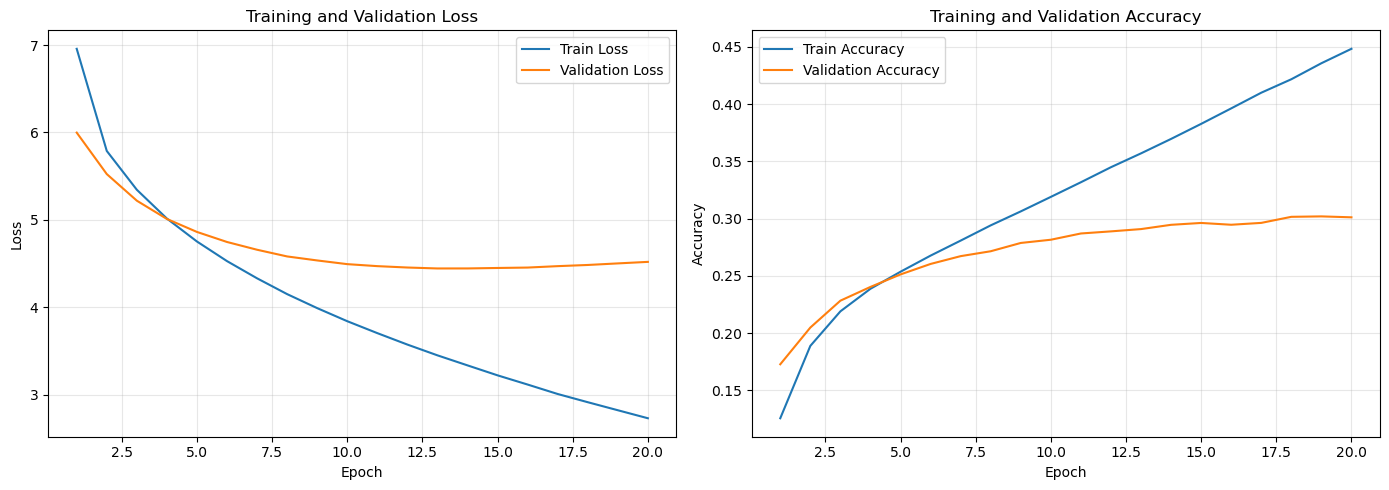

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
@torch.no_grad()
def generate(prompt, max_new=40, temperature=0.8, top_k=40, top_p=0.9):
    model.eval()
    ids = [BOS_ID] + sp.encode_as_ids(preprocess_sentence(prompt))
    x = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new):
        if x.size(1) >= MAX_POSITION:
            break
        logits = model(x)
        next_logits = logits[0, -1, :] / temperature

        # [핵심] top-k: 상위 k개만 남기고 나머지는 -∞로
        if top_k > 0:
            top_values = torch.topk(next_logits, top_k).values
            cutoff = top_values[-1]
            next_logits = torch.where(next_logits < cutoff,
                                      torch.full_like(next_logits, -float("inf")),
                                      next_logits)

        # [핵심] top-p: 누적확률 p를 넘는 후보부터 제거 (nucleus sampling)
        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cum_probs = torch.cumsum(sorted_probs, dim=-1)
            mask = cum_probs > top_p
            mask[1:] = mask[:-1].clone()
            mask[0] = False
            sorted_logits[mask] = -float("inf")
            next_logits = torch.full_like(next_logits, -float("inf"))
            next_logits.scatter_(0, sorted_indices, sorted_logits)

        probs = F.softmax(next_logits, dim=-1)
        next_id = int(torch.multinomial(probs, 1))
        if next_id == EOS_ID:
            break
        x = torch.cat([x, torch.tensor([[next_id]], device=device)], dim=1)

    generated_ids = x[0].tolist()[len(ids):]
    return sp.decode_ids(generated_ids)


# 테스트
for prompt in ["오늘 너무 힘들어", "12시 땡", "여자친구가 화났어"]:
    print(f"[입력] {prompt}")
    print(f"[출력] {generate(prompt)}")
    print("-" * 50)

[입력] 오늘 너무 힘들어
[출력] . 정말 힘드네 그래도 멋져요 .
--------------------------------------------------
[입력] 12시 땡
[출력] ! ! ! ! ! ! ! 맘고와요 .
--------------------------------------------------
[입력] 여자친구가 화났어
[출력] .밥 이겨질제 좀 더 찔서 상처받지 말고 조금만 해주세요 .
--------------------------------------------------


In [18]:
@torch.no_grad()
def generate(prompt, max_new=40, temperature=0.8, top_k=40, top_p=0.9):
    model.eval()
    ids = [BOS_ID] + sp.encode_as_ids(preprocess_sentence(prompt))
    x = torch.tensor([ids], dtype=torch.long, device=device)
    for _ in range(max_new):
        if x.size(1) >= MAX_POSITION:
            break
        logits = model(x)
        next_logits = logits[0, -1, :] / temperature
        # [핵심] top-k: 상위 k개만 남기고 나머지는 -∞로
        if top_k > 0:
            top_values = torch.topk(next_logits, top_k).values
            cutoff = top_values[-1]
            next_logits = torch.where(next_logits < cutoff,
                                      torch.full_like(next_logits, -float("inf")),
                                      next_logits)
        # [핵심] top-p: 누적확률 p를 넘는 후보부터 제거 (nucleus sampling)
        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cum_probs = torch.cumsum(sorted_probs, dim=-1)
            mask = cum_probs > top_p
            mask[1:] = mask[:-1].clone()
            mask[0] = False
            sorted_logits[mask] = -float("inf")
            next_logits = torch.full_like(next_logits, -float("inf"))
            next_logits.scatter_(0, sorted_indices, sorted_logits)
        probs = F.softmax(next_logits, dim=-1)
        next_id = int(torch.multinomial(probs, 1))
        if next_id == EOS_ID:
            break
        x = torch.cat([x, torch.tensor([[next_id]], device=device)], dim=1)
    generated_ids = x[0].tolist()[len(ids):]
    return sp.decode_ids(generated_ids)

# 테스트
prompts = [
    "오늘 너무 힘들어",
    "12시 땡",
    "여자친구가 화났어",
    "주말에 뭐할까",
    "배고파",
    "시험 망쳤어",
    "친구랑 싸웠어",
    "사랑이 뭘까",
    "회사 가기 싫다",
    "비 오는 날 좋아",
]
for prompt in prompts:
    print(f"[입력] {prompt}")
    print(f"[출력] {generate(prompt)}")
    print("-" * 50)

[입력] 오늘 너무 힘들어
[출력] . 제가 있잖아요 .
--------------------------------------------------
[입력] 12시 땡
[출력] 긴가는데 너무 많아 . 짝사랑은 나갈게 만들세요 .
--------------------------------------------------
[입력] 여자친구가 화났어
[출력] . 바쁘거나 마음이 없는 일이 많았어요 .
--------------------------------------------------
[입력] 주말에 뭐할까
[출력] 있어 . 잘 보이고 있어요 .
--------------------------------------------------
[입력] 배고파
[출력] 서서 너무 많지요 .
--------------------------------------------------
[입력] 시험 망쳤어
[출력] 너무 불안해 두려워하지 않아도 돼요 .
--------------------------------------------------
[입력] 친구랑 싸웠어
[출력] 혼자 먹어도 잘 지내는 게 좋죠
--------------------------------------------------
[입력] 사랑이 뭘까
[출력] ? 사랑은 알 수 없어요 .
--------------------------------------------------
[입력] 회사 가기 싫다
[출력] 마스크 받고 있나봐요 .
--------------------------------------------------
[입력] 비 오는 날 좋아
[출력] 신경 쓸지 마세요 .
--------------------------------------------------


# GPT-1 변경 사항 서술 (블록 단위)

기존 인코더-디코더 트랜스포머를 디코더-only GPT-1 구조로 변경하였다.
블록 단위로 변경 내역은 다음과 같다.

## 1. 인코더 블록 — 전체 삭제
- 기존: `Encoder` 클래스 (임베딩 + PositionalEncoding + N개의 `EncoderLayer`)
- 변경: 삭제. 디코더만 사용하는 단방향 언어모델이므로 인코더 자체가 필요 없다.

## 2. 디코더 블록 — Cross-Attention 제거
- 기존 `DecoderLayer`:
  ① `self_mha` (masked self-attention)
  ② `encdec_mha` (인코더 출력을 보는 cross-attention)
  ③ FFN
- 변경 `GPT1Block`:
  ① masked self-attention (유지)
  ② cross-attention 삭제 — 참조할 인코더 출력이 없음
  ③ FFN (활성함수 변경, 아래 7번 참고)
- 잔차연결·LayerNorm 두 개(어텐션 뒤·FFN 뒤)는 그대로 유지.

## 3. 어텐션 마스크 — 두 종류 → 한 종류로 통합
- 기존: 디코더가 두 마스크 사용
  ① `look_ahead_mask` (self-attn용, 미래 토큰 가리기)
  ② `padding_mask` (cross-attn용, PAD 가리기)
- 변경: cross-attn이 사라지면서 padding_mask가 self-attn 안으로 흡수됨.
- `create_look_ahead_mask`에서 `torch.maximum(look_ahead, padding)`으로 한 개의 마스크로 통합. 둘 중 하나라도 가려야 하면 가려진다.

## 4. 입력 블록 — 위치 인코딩 방식 변경 (GPT 논문 사양)
- 기존 `PositionalEncoding`: sin/cos 함수로 계산하는 고정 위치 인코딩 (`register_buffer`로 저장, 학습 안 됨).
- 변경: `nn.Embedding(max_position, d_model)` — 학습 가능한 위치 임베딩. 모델이 데이터로부터 위치 표현을 직접 학습한다.
- forward에서 `token_emb(x) + pos_emb(positions)`로 두 임베딩을 더해 입력으로 사용.

## 5. 출력 블록 — Vocabulary 사영 헤드
- 기존 `Transformer.final_linear`: 디코더 출력을 vocab 크기로 사영.
- 변경 `GPT1.head`: `nn.Linear(d_model, vocab_size)`. 구조는 동일하나 의미가 다르다.
- 기존은 seq2seq의 응답 토큰을 예측, GPT는 모든 위치에서 다음 토큰의 확률 분포를 출력한다. 손실은 시퀀스의 모든 위치(PAD 제외)에서 계산된다.

## 6. 모델 입력 — Two-tensor → Single-tensor
- 기존 `Transformer.forward(inputs, dec_inputs)`: 인코더 입력과 디코더 입력을 두 텐서로 받음.
- 변경 `GPT1.forward(x)`: `[BOS] + Q + A + [EOS]`를 이어붙인 한 텐서만 받음.
- 데이터셋도 이에 맞춰 `KoreanChatbotDataset → GPTDataset`으로 단순화:
  `(encoder_input, decoder_input, decoder_label)` → `(x, y)` 쌍, 여기서 `y = x[1:]` (한 칸 시프트된 정답).

## 7. FFN 블록 — 활성함수 변경
- 기존: `nn.Linear → nn.ReLU → nn.Linear`
- 변경: `nn.Linear → nn.GELU → nn.Linear` — GPT 논문이 사용한 활성함수로 교체.

---
※ LayerNorm 위치(post-norm), MultiHeadAttention 내부 구조, 잔차연결, Dropout은 기존 트랜스포머와 동일하게 유지하였다.
※ GPT-1의 pretrain(LM) 단계만 구현한다. 분류·요약 등 downstream fine-tune은 다루지 않는다.